In [1]:
import json
import pandas as pd
import re
import numpy as np

with open('games.json', encoding="utf8") as file:
    d=json.loads(file.read())

new_games_df = pd.DataFrame.from_dict(d).T.drop(['affiliate_links', 'backloggd_link', 'content', 'submitted_by', 'twitter_ids'], axis=1)
new_games_df["game"] = new_games_df['answers'].apply(lambda x: x[0])
new_games_df = new_games_df.drop(['answers'], axis=1)

def clear_platforms(x):
    x = re.sub(r'\(.*\)', '', x)
    if x.startswith('2020: PC'):
        return ['PC']
    x = x.replace(".", ",")
    x = x.split(",")
    x = [s.strip() for s in x]
    x = ["PS1" if s == "PS" else s for s in x]
    x = ["X360" if s == "360" else s for s in x]
    x = ["GameCube" if s == "Gamecube" else s for s in x]
    x = ["Xbox Series" if s == "X Series X/S" else s for s in x]
    x = ["Xbox Series" if s == "Series X/S" else s for s in x]
    x = ["Xbox Series" if s == "Xbox series" else s for s in x]
    x = ["Mac" if s == "Macintosh" else s for s in x]
    return x

new_games_df["console_platform"] = new_games_df["console_platform"].apply(clear_platforms)

def clear_genres(x):
    x = re.sub(r'\(.*\)', '', x)
    x = x.replace(".", ",")
    x = x.split(",")
    x = [s.strip().casefold() for s in x]
    return x

new_games_df["genre"] = new_games_df["genre"].apply(clear_genres)

def clear_metacritic(x):
    if x and x[0].isalpha():
        return None
    x = re.search(r"[0-9]+", x)
    return x.group(0)

new_games_df["metacritic_score"] = new_games_df["metacritic_score"].apply(clear_metacritic)
new_games_df["metacritic_score"] = new_games_df["metacritic_score"].astype(float)

new_games_df["release_year"] = new_games_df["release_year"].apply(lambda x: re.search(r"[0-9]{4}", x).group(0))
new_games_df["release_year"] = new_games_df["release_year"].astype(int)

new_games_df["day"] = new_games_df.index.astype(int)
new_games_df = new_games_df.set_index('day')

# Compute

In [3]:
# import results
f01 = open("gtg-jul26.txt", "r", encoding="utf8").read()

fulltext = '\n'.join([f01])

# specify beggining and end
from_day = 1509
to_day = 1539

fulltext = fulltext.replace("\n\n —", " —") # fix for new Discord badges


pasted = re.findall(r".* — [^#—]+#GuessTheGame #[0-9]*\n\n🎮(?:\s*[🟥🟨🟩⬜]){6}|#GuessTheGame #[0-9]*\n\n🎮(?:\s*[🟥🟨🟩⬜]){6}", fulltext)
pasted_all = re.findall(r"#GuessTheGame #[0-9]*\n\n🎮(?:\s*[🟥🟨🟩⬜]){6}", fulltext)

df = pd.DataFrame(pasted, columns=['full'])
df['name'] = df['full'].apply(lambda x: x.split(" — ")[0].strip()  if "—" in x else None)

df['day'] = df['full'].apply(lambda x: re.findall(r"#[0-9]+", x.split(" — ")[1].strip() if "—" in x else x)[0][1:])
df['day'] = df['day'].astype(int)

#df['guess'] = df['full'].apply(lambda x: re.findall("[🟥🟨🟩⬜]", x).index("🟩") if "🟩" in re.findall("[🟥🟨🟩⬜]", x) else np.nan)
df['guess'] = df['full'].apply(lambda x: re.findall(r"[🟥🟨🟩⬜]", x).index("🟩") if "🟩" in re.findall(r"[🟥🟨🟩⬜]", x) else 5.5 if "🟨" in re.findall(r"[🟥🟨🟩⬜]", x) else np.nan)

df['score'] = ((df['guess']) * -1) + 6
df.loc[np.isnan(df['score']), 'score'] = 0

df['days played'] = 1

df['guess'] = df['guess'] + 1

df.loc[np.isnan(df['guess']), 'guess'] = 7

df = df.ffill()

df = df[(df.day >= from_day) & (df.day <= to_day)]

# TODO: assert there are no duplicates

df = df.drop_duplicates(subset=['name', 'day'])

difficulty_index = df.groupby(['day']).agg({'score':'sum'}).sort_values(by='score')
difficulty_index = difficulty_index.rename(columns={"score": "day_difficulty"})
difficulty_index_copy = difficulty_index.copy()
difficulty_index_copy.loc[difficulty_index_copy["day_difficulty"] == 0, "day_difficulty"] = 1.0

df = df.join(difficulty_index_copy, on='day')

df['AW hipster score'] = (df['score'] / df['day_difficulty'] * 100).astype(int)

df = df.join(new_games_df, on='day')

df['decade'] = df['release_year'].apply(lambda x: x // 10 * 10)

df_final = df.groupby(['name']).agg({'score':'sum', 'days played':'sum', 'guess':'mean'}).sort_values(by=['score', 'name'], ascending=[False, True])
df_final['guess'] = df_final['guess'].round(2)
df_final = df_final.rename(columns={"guess": "mean correct guess", "score": "total score"})
#df_final['median correct guess'] = df.groupby(['name']).agg({'guess':'median'}).astype(int)
df_final["total score"] = df_final["total score"]
df_final = df_final.reset_index()
df_final.index += 1
df_final

,name,total score,days played,mean correct guess
1,yablko,105.0,30,3.50
2,Hades🐍,94.0,31,3.97
3,boomer,87.0,31,4.19
4,Joey Vancouver,77.5,31,4.50
5,Naga,76.5,31,4.53
6,hostinko,74.0,30,4.53
7,tapiq,70.5,31,4.73
8,Drobec,70.0,31,4.74
9,Tulex,67.0,31,4.84
10,vulo,61.0,31,5.03


In [7]:
from IPython.display import display, HTML
pd.set_option('display.max_colwidth', 255)

def pretty_print(df):
    return display( HTML( df.to_html().replace("\\n","<br>") ) )

hipster_score_2 = df.copy().groupby(['name','AW hipster score'])['game'].apply(lambda x: '\n'.join(x)).reset_index().sort_values(by=['AW hipster score', 'name'], ascending=[False, True]).drop_duplicates(['name'])
hipster_score_2.index = np.arange(len(hipster_score_2)) + 1
pretty_print(hipster_score_2[hipster_score_2["AW hipster score"] > 0])

,name,AW hipster score,game
1,Joey Vancouver,100,El Shaddai: Ascension of the Metatron
2,Naga,83,Wonder Boy III: The Dragon's Trap
3,Drobec,50,Rec Room
4,Celo,37,Abiotic Factor
5,boomer,35,F-Zero GX
6,Hades🐍,33,Shadowrun
7,yablko,33,Shadowrun
8,Diagnostik#7552,30,Manor Lords
9,HusKy,25,Abiotic Factor
10,Tulex,25,Abiotic Factor


In [39]:
hipster_score = df.copy().sort_values(by=['AW hipster score', 'name'], ascending=[False, True]).drop_duplicates(['name'])[['name', 'day', 'guess', 'AW hipster score']]
hipster_score['day'] = hipster_score['day'].astype("Int64")
hipster_score["guess"] = hipster_score["guess"].astype(int)
hipster_score = hipster_score.join(new_games_df[['game', 'release_year']], on='day')
hipster_score['AW hipster score'] = hipster_score['AW hipster score'].round(2)
hipster_score.index = range(len(hipster_score))
hipster_score.index += 1
hipster_score

,name,day,guess,AW hipster score,game,release_year
1,Joey Vancouver,1536,1,100,El Shaddai: Ascension of the Metatron,2011
2,Naga,1538,2,83,Wonder Boy III: The Dragon's Trap,1989
3,Drobec,1512,2,50,Rec Room,2016
4,Celo,1515,4,37,Abiotic Factor,2024
5,boomer,1531,2,35,F-Zero GX,2003
6,Hades🐍,1516,6,33,Shadowrun,2007
7,yablko,1516,6,33,Shadowrun,2007
8,Diagnostik#7552,1519,1,30,Manor Lords,2024
9,HusKy,1515,5,25,Abiotic Factor,2024
10,Tulex,1515,5,25,Abiotic Factor,2024


In [40]:
difficulty_index.join(new_games_df['game'], on='day').head(7)

,day_difficulty,game
day,,
1513,0.0,Inherit the Earth: Quest for the Orb
1516,3.0,Shadowrun
1536,6.0,El Shaddai: Ascension of the Metatron
1538,6.0,Wonder Boy III: The Dragon's Trap
1515,8.0,Abiotic Factor
1512,10.0,Rec Room
1520,13.0,The Warriors


In [41]:
difficulty_index.join(new_games_df['game'], on='day').sort_values(by='day_difficulty', ascending=False).head(7)

,day_difficulty,game
day,,
1517,71.0,Starcraft
1534,68.0,Phonopolis
1535,65.0,Red Dead Redemption
1532,62.0,Psychonauts
1537,60.0,Blue Prince
1518,57.0,Mina the Hollower
1514,54.0,Stray


In [42]:
points = [25, 18, 15, 12, 10, 8, 6, 4, 2, 1]

df_rankings = df_final[['name', 'total score']].merge(hipster_score_2[['name', 'AW hipster score']], on='name', how='outer')
df_rankings["total score points"] = 0
df_rankings["hipster score points"] = 0

for i, winner in enumerate(df_final.head(10).name):
    df_rankings.loc[df_rankings.name == winner, 'total score points'] = points[i]

df_rankings = df_rankings.sort_values(by=['total score', 'name'], ascending=[False, True])
df_rankings = df_rankings.reset_index()

for i in range(len(df_rankings) - 1):
    if df_rankings.loc[i, 'total score'] == df_rankings.loc[i+1, 'total score']:
        df_rankings.loc[i+1, 'total score points'] = df_rankings.loc[i, 'total score points']

for i, winner in enumerate(hipster_score_2.head(3).name):
    df_rankings.loc[df_rankings.name == winner, 'hipster score points'] = points[-3+i]

df_rankings = df_rankings.sort_values(by=['AW hipster score', 'name'], ascending=[False, True])
df_rankings = df_rankings.reset_index()

# override for hipster score points
for i in range(len(df_rankings) - 1):
   if df_rankings.loc[i, 'AW hipster score'] == df_rankings.loc[i+1, 'AW hipster score']:
       df_rankings.loc[i+1, 'hipster score points'] = max(df_rankings.loc[i, 'hipster score points'],df_rankings.loc[i+1, 'hipster score points'])
       df_rankings.loc[i, 'hipster score points'] = max(df_rankings.loc[i, 'hipster score points'],df_rankings.loc[i+1, 'hipster score points'])

df_rankings['final points'] = df_rankings['total score points'] + df_rankings['hipster score points']
df_rankings = df_rankings.sort_values(by=['final points', 'name'], ascending=[False, True])
df_rankings = df_rankings.reset_index(drop=True)
df_rankings = df_rankings.drop(columns='index')
df_rankings.index += 1
df_rankings[df_rankings["final points"] > 0][['name', 'total score points', 'hipster score points', 'final points']]

,name,total score points,hipster score points,final points
1,yablko,25,0,25
2,Hades🐍,18,0,18
3,Joey Vancouver,12,4,16
4,boomer,15,0,15
5,Naga,10,2,12
6,hostinko,8,0,8
7,tapiq,6,0,6
8,Drobec,4,1,5
9,Tulex,2,0,2
10,vulo,1,0,1


In [43]:
df_rankings[df_rankings["final points"] > 0][['name', 'final points']]

,name,final points
1,yablko,25
2,Hades🐍,18
3,Joey Vancouver,16
4,boomer,15
5,Naga,12
6,hostinko,8
7,tapiq,6
8,Drobec,5
9,Tulex,2
10,vulo,1


In [44]:
rankings_year = pd.read_csv("points2026.csv")
rankings_year = rankings_year.drop(["Unnamed: 0"], axis=1)
rankings_year

#rankings_year.drop(["march"], axis=1, inplace=True)
#rankings_year

#rankings_year = df_rankings[df_rankings["final points"] > 0][['name', 'final points']]
#rankings_year["total"] = rankings_year["final points"]

,name,january,february,march,april,may,june,total
0,Hades🐍,27,12,25,25,18,17,124
1,boomer,18,15,15,16,25,29,118
2,Joey Vancouver,4,18,29,18,19,18,106
3,yablko,6,27,0,15,12,13,73
4,HusKy,15,14,12,6,8,4,59
5,hostinko,10,8,6,10,8,6,48
6,Drobec,1,0,12,10,10,0,33
7,Tulex,1,8,8,1,4,0,22
8,Diagnostik#7552,0,0,10,4,0,4,18
9,Mako,0,4,0,0,0,10,14


In [45]:
rankings_year = rankings_year.merge(df_rankings[df_rankings["final points"] > 0][['name', 'final points']], on='name', how='outer')
rankings_year = rankings_year.fillna(value = 0)
rankings_year = rankings_year.rename(columns={"final points": "july"})
rankings_year = rankings_year[[c for c in rankings_year if c not in ['total']] + ['total']]

cols = rankings_year.columns[1:-1]
rankings_year[cols] = rankings_year[cols].astype(int)

rankings_year['total'] = rankings_year.iloc[:, 1:-1].sum(axis=1)
rankings_year = rankings_year.sort_values(by='total', ascending=False).reset_index()
rankings_year = rankings_year.drop(columns='index')
rankings_year.index += 1
rankings_year

,name,january,february,march,april,may,june,july,total
1,Hades🐍,27,12,25,25,18,17,18,142
2,boomer,18,15,15,16,25,29,15,133
3,Joey Vancouver,4,18,29,18,19,18,16,122
4,yablko,6,27,0,15,12,13,25,98
5,HusKy,15,14,12,6,8,4,0,59
6,hostinko,10,8,6,10,8,6,8,56
7,Drobec,1,0,12,10,10,0,5,38
8,Tulex,1,8,8,1,4,0,2,24
9,Diagnostik#7552,0,0,10,4,0,4,0,18
10,Naga,0,4,0,0,1,0,12,17


In [46]:
rankings_year.to_csv("points2026.csv")

In [47]:
cumulative = rankings_year.iloc[:, 1:-1].cumsum(axis=1)
cumulative["name"] = rankings_year["name"]
cumulative

,january,february,march,april,may,june,july,name
1,27,39,64,89,107,124,142,Hades🐍
2,18,33,48,64,89,118,133,boomer
3,4,22,51,69,88,106,122,Joey Vancouver
4,6,33,33,48,60,73,98,yablko
5,15,29,41,47,55,59,59,HusKy
6,10,18,24,34,42,48,56,hostinko
7,1,1,13,23,33,33,38,Drobec
8,1,9,17,18,22,22,24,Tulex
9,0,0,10,14,14,18,18,Diagnostik#7552
10,0,4,4,4,5,5,17,Naga


C:\Users\peter\AppData\Local\Temp\ipykernel_12304\3880892812.py:23: UserWarning: Glyph 128013 (\N{SNAKE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\peter\.conda\envs\gtg\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128013 (\N{SNAKE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


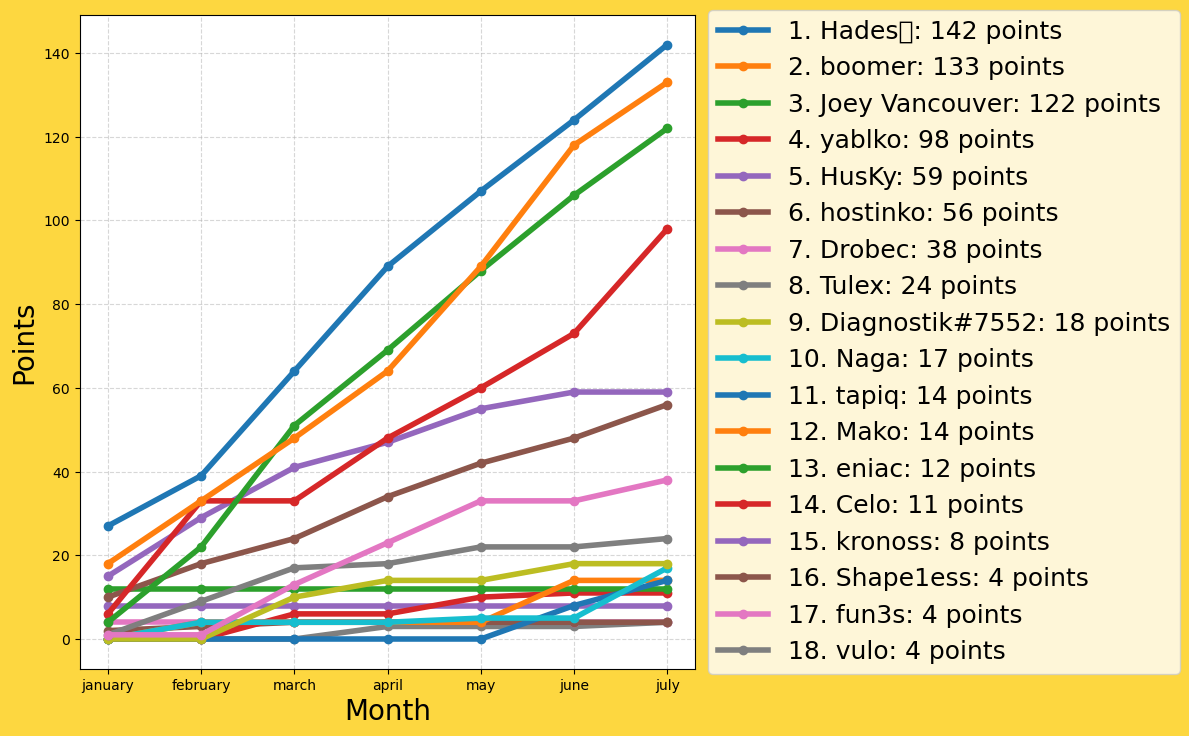

In [48]:
import matplotlib.pyplot as plt
cumulative = rankings_year.iloc[:, 1:-1].cumsum(axis=1)
cumulative["name"] = rankings_year["name"]

fig, ax = plt.subplots(figsize=(12, 7.75), facecolor="#fdd740")

for i, row in cumulative.iterrows():
    ax.plot(rankings_year.iloc[:, 1:-1].columns, row.values[0:-1], 'o-', label=f"{i}. {row['name']}: {row.values[-2]} points", linewidth=4, zorder=100-i)
    # Annotate name at the last point
    #plt.text(x=4.3, y=row.values[-2], s=row['name'],
    #         va='center', ha='left', fontsize=12)
    
#names_points = cumulative.groupby(cumulative.columns[-2])['name'].agg(', '.join).reset_index()
#for i, row in names_points.iterrows():
#    plt.text(x=1.1, y=row.values[-2], s=row['name'] + f": {row.values[-2]}",
#             va='center', ha='left', fontsize=12, rotation=0, rotation_mode='anchor')

#plt.title('Arcade Watch GtG League Points Over Time')
plt.xlabel('Month', fontsize=20)
plt.ylabel('Points', fontsize=20)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=18)
plt.tight_layout()
plt.show()

c:\Users\peter\.conda\envs\gtg\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128013 (\N{SNAKE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\peter\.conda\envs\gtg\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128013 (\N{SNAKE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


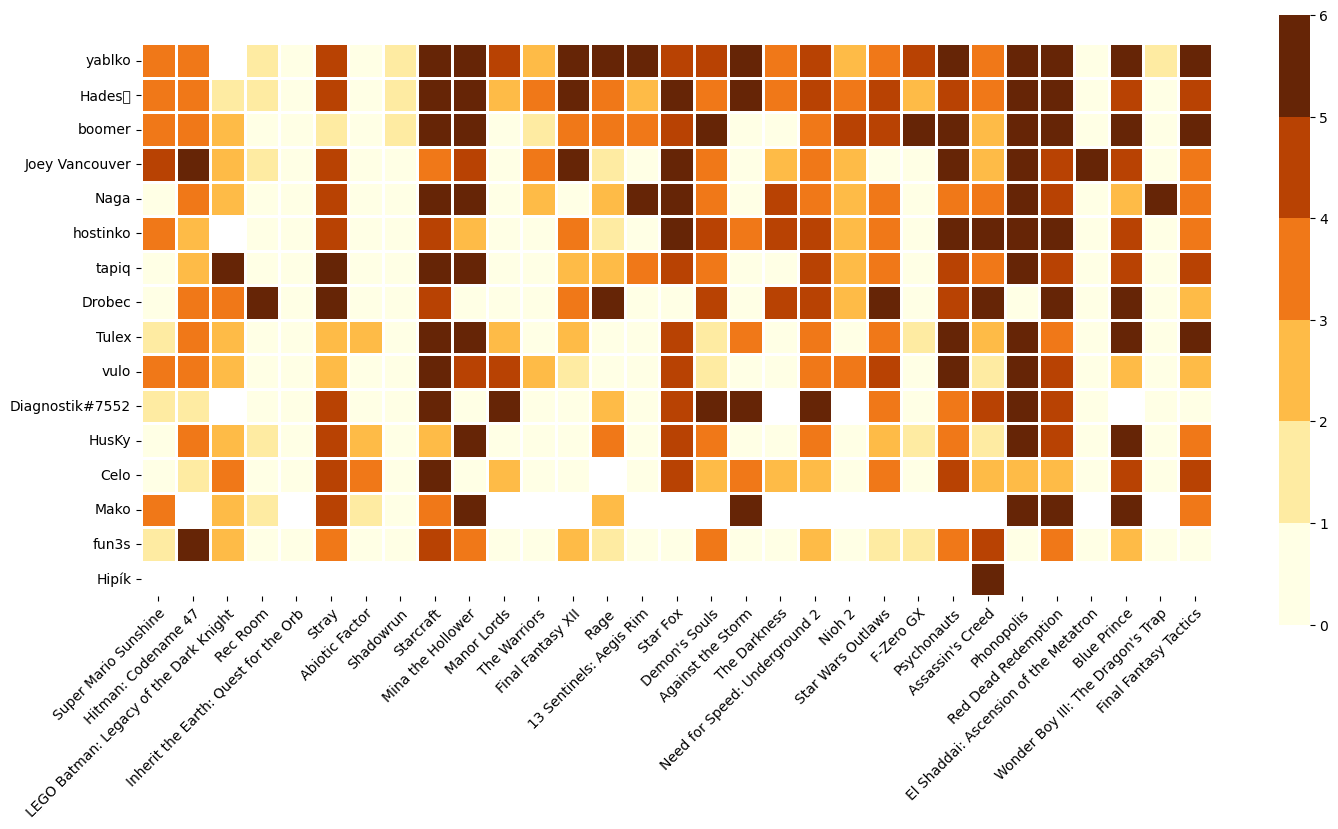

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

matrix_df = df.pivot(index="name", columns="day", values="score")

# 3. Reorder the matrix using the sorted names
matrix_ordered = matrix_df.loc[df_final.name]

# Set up the figure size based on your matrix shape
plt.figure(figsize=(15, 8))

segmented_cmap = plt.get_cmap("YlOrBr", 6)

# Plot the heatmap
sns.heatmap(
    matrix_ordered, 
    cmap=segmented_cmap,        # GitHub-style green shading
    linewidths=2,         # Spacing between the blocks ("dots")
    linecolor="white",    # Grid line color matching the background
    square=True,          # Forces cells to be perfectly square
    cbar=True,            # Set to False if you don't want the color intensity scale
    mask=matrix_ordered.isnull() # Automatically leaves NaNs as empty/white space
)

plt.xlabel(None)
plt.ylabel(None)
new_labels = new_games_df.loc[matrix_ordered.columns, 'game']

# 2. Apply the new labels to the current x-ticks positions
plt.xticks(
    ticks=np.arange(len(matrix_ordered.columns))+0.5, 
    labels=new_labels, 
    rotation=45, 
    rotation_mode='anchor',
    ha="right"
)

plt.tight_layout()
plt.show()

In [51]:
matrix_ordered

day,1509,1510,1511,1512,1513,1514,1515,1516,1517,1518,...,1530,1531,1532,1533,1534,1535,1536,1537,1538,1539
name,,,,,,,,,,,,,,,,,,,,,
yablko,3.0,3.0,NaN,1.0,0.0,4.0,0.0,1.0,5.0,6.0,...,3.0,4.0,6.0,3.0,6.0,5.0,0.0,5.0,1.0,5.0
Hades🐍,3.0,3.0,1.0,1.0,0.0,4.0,0.0,1.0,6.0,5.0,...,4.0,2.0,4.0,3.0,5.0,5.0,0.0,4.0,0.0,4.0
boomer,3.0,3.0,2.0,0.0,0.0,1.0,0.0,1.0,6.0,5.0,...,4.0,5.0,6.0,2.0,6.0,6.0,0.0,5.0,0.0,6.0
Joey Vancouver,4.0,5.0,2.0,1.0,0.0,4.0,0.0,0.0,3.0,4.0,...,0.5,0.0,6.0,2.0,5.0,4.0,6.0,4.0,0.0,3.0
Naga,0.5,3.0,2.0,0.0,0.0,4.0,0.0,0.0,6.0,6.0,...,3.0,0.0,3.0,3.0,6.0,4.0,0.0,2.0,5.0,3.0
hostinko,3.0,2.0,NaN,0.0,0.0,4.0,0.0,0.0,4.0,2.0,...,3.0,0.0,6.0,5.0,6.0,6.0,0.0,4.0,0.0,3.0
tapiq,0.5,2.0,5.0,0.0,0.0,5.0,0.0,0.0,5.0,5.0,...,3.0,0.0,4.0,3.0,6.0,4.0,0.0,4.0,0.0,4.0
Drobec,0.0,3.0,3.0,5.0,0.0,5.0,0.0,0.0,4.0,0.0,...,5.0,0.0,4.0,5.0,0.0,6.0,0.0,6.0,0.0,2.0
Tulex,1.0,3.0,2.0,0.0,0.0,2.0,2.0,0.0,6.0,6.0,...,3.0,1.0,5.0,2.0,5.0,3.0,0.0,6.0,0.0,5.0
